# Vježbe 4

## Implementacija perceptron algoritma

Implementirajte perceptron algoritam koji rješava problem binarne klasifikacije. Dobivena hiperravnina ne mora nužno prolaziti kroz ishodište. Točku $x \in \mathbb{R}^n$ u nastavku možete prikazivati kao $x = (x_0, x_1, \dots, x_n)^T \in \mathbb{R}^{n+1}$, gdje je $x_0 = 1$.

Vaši zadaci su sljedeći:
 1. Implementirajte perceptron algoritam koji na ulazu prima podatke $X \in \mathbb{R}^{m \times (n+1)}$, klase $y \in \{-1, 1\}^m$ i maksimalan broj iteracija *max_iter* te vraća uređen par $(\Theta, k)$, gdje je $\Theta \in \mathbb{R}^{n+1}$ vektor koji definira hiperravninu, a $k$ broj iteracija potreban za konvergenciju.
 2. Implementirajte funkciju `accuracy`, koja za dane podatke $X$ i klase $y$ računa udio točaka koje je perceptron točno klasificirao.
 3. Učitajte skupove podataka `A.csv`, `B.csv` i `C.csv`. U prva dva stupca se nalaze koordinate točaka $x$, dok su u zadnjem stupcu oznake klasa. Na svakom od skupova pokrenite perceptron algoritam i ispišite dobivene vrijednosti $\Theta$ i $k$. Uvjerite se da su podaci točno (ili netočno) klasificirani koristeći funkciju iz podzadatka 2.
 4. Grafički prikažite sva tri skupa podataka i pripadne hiperravnine $\Theta{}^Tx = 0$. Podaci iz različitih klasa trebaju imati različite boje.
 5. Izračunajte vrijednosti geometrijskih margina $\gamma_{\textrm{geom}}$ za sva tri skupa podataka. Argumentirajte zašto je teže klasificirati točke iz skupa B nego točke iz skupa A.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Podsjetimo se funkcije model za klasifikaciju
$$h_\theta(x) = sign(\theta^T x)$$
i funkcije cilja
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (1 - \delta(h_\theta(x^{(i)}), y^{(i)}))$$

gdje je $\delta$ indikator funkcija.

In [3]:
class Perceptron:
    def __init__(self, X, y, learning_rate = 0.01, max_iter = 1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.X = np.hstack((np.ones((X.shape[0], 1)), X))
        self.y = y
        self.theta = None
        self.m = self.X.shape[0] #broj podataka
        self.n = self.X.shape[1] #broj znacajki (+1 u odnosu na originalni X)

    def fit(self):
        #izračunamo predikciju
        #ako je predikcija točna, ne radimo ništa
        #ako je predikcija netočna, ažuriramo thetu
        #ako je y[i] = 1, a y_pred = 0, onda želimo povećati theta^T x_i
        #ako je y[i] = 0, a y_pred = 1, onda želimo smanjiti theta^T x_i
        self.theta = np.random.rand(self.n)
        for _ in range(self.max_iter):
            for i in range(self.m):
                y_pred = self.predict(self.X[i])
                if y_pred == self.y[i]:
                    continue
                self.theta += self.learning_rate * (self.y[i] - y_pred) * self.X[i]

    def accuracy(self, X, y):
        #tretiramo X i y kao odvojene od onih nad kojima se trenirao model
        m = X.shape[0] #getaj broj podataka
        score = 0
        #prosiri testni X
        X = np.hstack((np.ones((m, 1)), X))
        #za svaki podatak izracunaj predikciju
        for i in range(m):
            if self.predict(X[i]) * y[i] > 0:
                score += 1
        
        return score / m
    
    def predict(self, x):
        #izračunamo theta^T x
        #ako je z >= 0, predikcija je 1, inače je 0
        return np.sign(self.theta @ x)
    
    def draw(self, X, y):
        #model je u 2D i natreniran je
        if self.theta is not None and self.theta.shape[0] == 3:
            plt.scatter(X[:, 0], X[:, 1], c=y) #podaci
            x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100) #od najmanje do najvece vrijednosti x koordinate i 100 tocaka
            x2 = -(self.theta[0] + self.theta[1] * x1) / self.theta[2]
            plt.plot(x1, x2, 'r')
            plt.show()
        else:
            print("Model nije natraniran ili je dimenzija veca od 2!")

    def geometric_margin(self, X, y):
        m = X.shape[0]
        X = np.hstack((np.ones((m, 1)), X))
        margins = np.zeros(m) #postavi sve margine na 0, imamo ih koliko i podataka
        for i in range(m):
            margins[i] = y[i] * (self.theta @ X[i]) / np.linalg.norm(self.theta)
        return margins


In [5]:
dfA = pd.read_csv("podaci/A.csv")
dfB = pd.read_csv("podaci/B.csv")
dfC = pd.read_csv("podaci/C.csv")

In [6]:
XA = np.array(dfA[["x1", "x2"]])
XB = np.array(dfB[["x1", "x2"]])
XC = np.array(dfC[["x1", "x2"]])
yA = np.array(dfA["y"])
yB = np.array(dfB["y"])
yC = np.array(dfC["y"])

X_trainA, X_testA, y_trainA, y_testA = train_test_split(XA, yA, test_size=0.2, random_state=42)
X_trainB, X_testB, y_trainB, y_testB = train_test_split(XB, yB, test_size=0.2, random_state=42)
X_trainC, X_testC, y_trainC, y_testC = train_test_split(XC, yC, test_size=0.2, random_state=42)

percA = Perceptron(X_trainA, y_trainA)
percB = Perceptron(X_trainB, y_trainB)
percC = Perceptron(X_trainC, y_trainC)

In [7]:
percA.fit()
percB.fit()
percC.fit()

In [8]:
percA.accuracy(X_testA, y_testA), percB.accuracy(X_testB, y_testB), percC.accuracy(X_testC, y_testC)

(1.0, 1.0, 0.83)

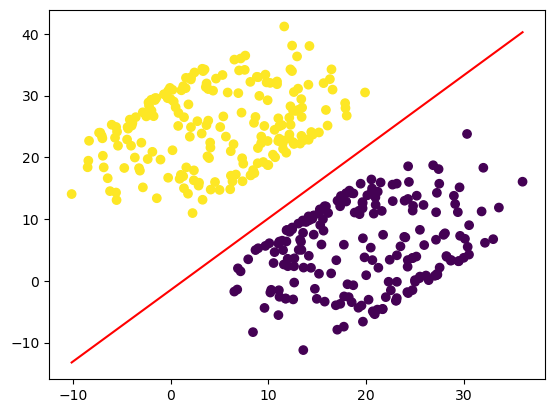

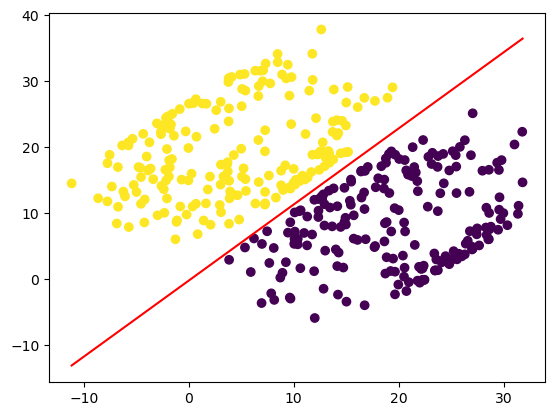

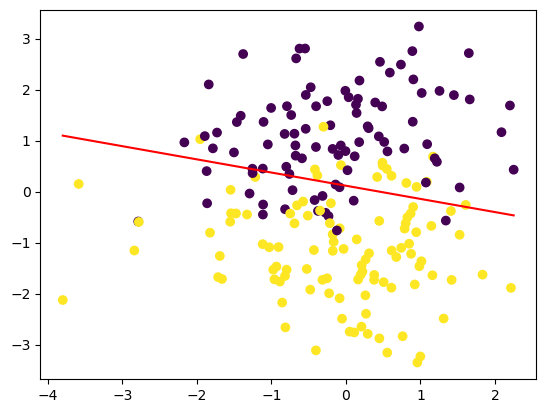

(None, None, None)

In [9]:
percA.draw(X_testA, y_testA), percB.draw(X_testB, y_testB), percC.draw(X_testC, y_testC)

In [10]:
percA.geometric_margin(X_testA, y_testA).min(), percB.geometric_margin(X_testB, y_testB).min(), percC.geometric_margin(X_testC, y_testC).min()

(1.6903513589608223, 0.5018212693653502, -1.3686373158731404)

# Zadatak: Transformacija linearno neseparabilnih podataka

U datoteci `nonlinsep.csv` zadan je linearno neseparabilan skup podataka iz $\mathbb{R}^2$ (u istom formatu kao prethodni skupovi podataka).

### Vizalizacija
Vizulizirajte podatke tako da obojate različite klase različitim bojama.

In [11]:
df_nonlinsep = pd.read_csv("podaci/nonlinsep.csv")
df_nonlinsep["x1"].shape

(1454,)

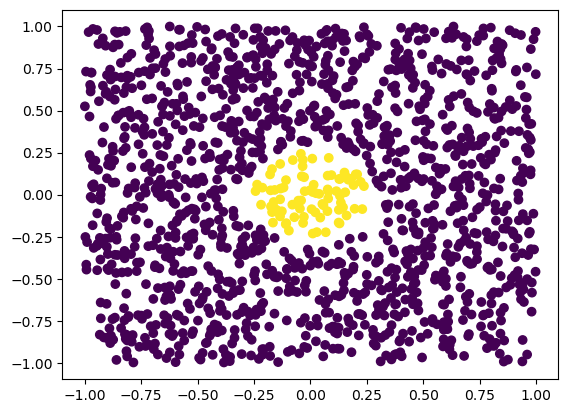

In [13]:
nonlin_df = pd.read_csv('./podaci/nonlinsep.csv')
X_nonlin = np.array(nonlin_df[['x1', 'x2']])
y_nonlin = np.array(nonlin_df['y'])

plt.scatter(X_nonlin[:, 0], X_nonlin[:, 1], c = y_nonlin)
plt.show()

### Koja to funkcija separira podatke i kako glasi $h(x)$?

Kružnica separira podatke. Klasifikacijska funkcija može glasiti (radijus je otprilike $\frac{1}{4}$)
$$
h(x) = x_1^2 + x_2^2 - \left(\frac{1}{4}\right)^2.
$$

### Razdvojite podatke u tako da ostanete u istom prostoru
Nove podatke nazovite X_per te ih nacrtajte nakon transformacije.

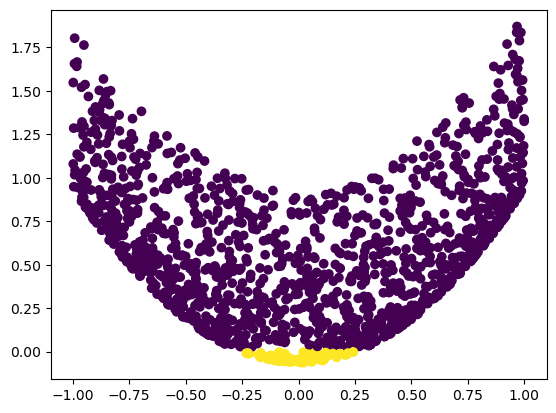

In [14]:
m = X_nonlin.shape[0]
X_per = np.empty((m, 2))


for i in range(m):
    #novi x_0  = x_1

    X_per[i, 0] = X_nonlin[i, 1]
    #novi x_1 = x_1^2 + x_2^2  - (1/4)**2
    X_per[i, 1] = np.sum(np.square(X_nonlin[i]))  - (1/4)**2

plt.scatter(X_per[:, 0], X_per[:, 1], c = y_nonlin)
plt.show()

### Natrenirajte model
Podatke standardno razdvojite na 80-20 omjer, ispišite preciznost te nacrtajte pravac i testne podatke. Na kraju ispišite najmanju vrijednost geometrijske margine za testne podatke.

In [ ]:
#A.csv treniranje i razdvajanje na 80/20
